## Chains in Langgraph

How we can build a simple chain using Langgraph that uses:
1. How to use chat messages as our graph state
2. How to use Chat models in graph nodes
3. How to bind tools to our LLM in chat models
4. How to execute the tools call in our graph nodes

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'GROQ_API_KEY: {GROQ_API_KEY[:3]}**{GROQ_API_KEY[-3:]}')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
assert OPENAI_API_KEY
print(f'OPENAI_API_KEY: {OPENAI_API_KEY[:3]}**{OPENAI_API_KEY[-3:]}')

GROQ_API_KEY: gsk**qNU
OPENAI_API_KEY: sk-**tIA


## How to use Chat Messages as Graph state

#### Messages

We can use messages which can be used to capture different roles within the conversation. Langchain has various message types including **HumanMessage**, **AIMessage**, **SystemMessage** and **ToolMessage**. These represents a message from the user, from chat model, for the chat model to instruct behaviour, and from a tool call.

Every message has these important components:
- `content` - content of the message
- `name` - specify name of the author
- `response_metadata` - optionally, a dict of metadata (e.g. often populated by model provider for **AIMessages**)


In [6]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from pprint import pprint

messages = [
    AIMessage(content='Please tell me how can I help you?', name='LLM Model'),
    HumanMessage(content='I want to learn coding', name= 'Dimo'),
    AIMessage(content='Tell me which programming language you want to learn?', name='LLM Model'),
    HumanMessage(content='I want to became Python master', name='Dimo')
]

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLM Model

Please tell me how can I help you?
================================ Human Message =================================
Name: Dimo

I want to learn coding
================================== Ai Message ==================================
Name: LLM Model

Tell me which programming language you want to learn?
================================ Human Message =================================
Name: Dimo

I want to became Python master


#### Chat models

We can use the sequence of messages as input with the chatmodels using LLMs and OpenAI.



In [7]:
from langchain_groq import ChatGroq
groq_chat = ChatGroq(model='Gemma2-9b-It')
response = groq_chat.invoke(messages)
response

AIMessage(content="That's awesome! Python is a fantastic language to learn, versatile and beginner-friendly. \n\nTo help you on your journey to Python mastery, tell me:\n\n1. **What's your current experience with coding?**  \n\n   * Are you a complete beginner?\n   * Have you dabbled in other languages before?\n\n2. **What are your goals for learning Python?**\n\n   * Do you want to build websites, analyze data, work with artificial intelligence, or something else entirely?\n\n3. **How do you prefer to learn?**\n\n   * Online courses, books, interactive tutorials, or a combination?\n\n\nOnce I have this information, I can give you more personalized advice and resources. Let's get started!\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 159, 'prompt_tokens': 59, 'total_tokens': 218, 'completion_time': 0.289090909, 'prompt_time': 0.00178595, 'queue_time': 0.186764636, 'total_time': 0.290876859}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c

## Tools 

Tools can be integrated with the LLM to interact with external systems. External systems can be API's, third party tools.

Whenevet a query is asked, the model can choose to call the tool and this query is based on natural language input and this will return an output that matches the tool's schema. 

In [7]:
def add(a: int, b: int) -> int:
    """Find sum of 2 integers a and b

    Args:
        a (int): first integer
        b (int): second integer

    Returns:
        int: The sum of a and b
    """
    return a + b

In [ ]:
# Binding tool with llm (GroqChat)
groq_chat_with_tools = groq_chat.bind_tools([add])

response = groq_chat_with_tools.invoke([HumanMessage(content='What is the sum of 1924124 and 1242')])
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rqjmr4d88', 'function': {'arguments': '{"a":1924124,"b":1242}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 998, 'total_tokens': 1092, 'completion_time': 0.170909091, 'prompt_time': 0.0222065, 'queue_time': 0.188238426, 'total_time': 0.193115591}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c1e285af-baad-4fa7-899f-83c08dffd974-0', tool_calls=[{'name': 'add', 'args': {'a': 1924124, 'b': 1242}, 'id': 'rqjmr4d88', 'type': 'tool_call'}], usage_metadata={'input_tokens': 998, 'output_tokens': 94, 'total_tokens': 1092})

In [11]:
response.tool_calls

[{'name': 'add',
  'args': {'a': 1924124, 'b': 1242},
  'id': 'rqjmr4d88',
  'type': 'tool_call'}]

### Using messages as State

In [ ]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages: list[AnyMessage]

##### Reducers
Now we have a minor problem!

Each node will return a new value for our State key messages. But, this new value will override the prior messages value. As our graph runs, we want to append messages to our messages state key.

We can use **reducer functions** to achieve this.
Reducers allow us to specify how state updates are performed. If **NO reducer** function is specified, then it is assumed that updates to the key will **override** it.

To append messages we can use the pre-built reducer **add_messages**.
This ensures that any messages are appended to the existing list of messages. We simply simply need to annotate our messages key with the `add_messages` reducer function as metadata.


In [3]:
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [4]:
# Node functionality
def tool_call(state: State):
    return { 'messages': [groq_chat_with_tools.invoke(state['messages'])] }

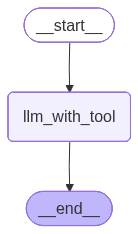

In [5]:
# Define the state graph
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

# Nodes
graph_builder.add_node('llm_with_tool', tool_call)

# Edges
graph_builder.add_edge(START, 'llm_with_tool')
graph_builder.add_edge('llm_with_tool', END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
# Invokation

input_messages = [HumanMessage(content='What is the sum of 124235 and 234211')]
response = graph.invoke(input={
    'messages': input_messages
})
response

{'messages': [HumanMessage(content='What is the sum of 124235 and 234211', additional_kwargs={}, response_metadata={}, id='e762e164-8bdc-48ab-bd21-e14e2a78e49a'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'eds0yd8dr', 'function': {'arguments': '{"a":124235,"b":234211}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 999, 'total_tokens': 1095, 'completion_time': 0.174545455, 'prompt_time': 0.02115168, 'queue_time': 0.189398993, 'total_time': 0.195697135}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--56e90c39-3ee8-4b92-97a1-350acfbc2e28-0', tool_calls=[{'name': 'add', 'args': {'a': 124235, 'b': 234211}, 'id': 'eds0yd8dr', 'type': 'tool_call'}], usage_metadata={'input_tokens': 999, 'output_tokens': 96, 'total_tokens': 1095})]}

In [20]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the sum of 124235 and 234211
================================== Ai Message ==================================
Tool Calls:
  add (eds0yd8dr)
 Call ID: eds0yd8dr
  Args:
    a: 124235
    b: 234211


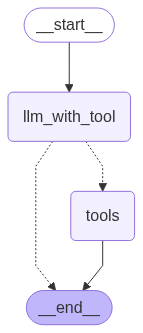

In [8]:
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)

tools = [add]

# Nodes
graph_builder.add_node('llm_with_tool', tool_call)
graph_builder.add_node('tools', ToolNode(tools=tools))

# Edges
graph_builder.add_edge(START, 'llm_with_tool')
graph_builder.add_conditional_edges(
    'llm_with_tool', 
    # If the latest message (result) from assistant is a tool call -> tools conditions routes to tools
    # If the latest message (result) from assistant is NOT a tool call -> tools conditions routes to END
    tools_condition)
graph_builder.add_edge('tools', END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
# Invokation

input_messages = [HumanMessage(content='What is the sum of 124235 and 234211')]
response = graph.invoke(input={
    'messages': input_messages
})
response

{'messages': [HumanMessage(content='What is the sum of 124235 and 234211', additional_kwargs={}, response_metadata={}, id='fa559ea4-3320-4d7e-8375-af106be17a69'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1d7tpb4qp', 'function': {'arguments': '{"a":124235,"b":234211}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 999, 'total_tokens': 1095, 'completion_time': 0.174545455, 'prompt_time': 0.019130519, 'queue_time': 0.188635847, 'total_time': 0.193675974}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--2f8ba9ea-c176-48d6-83df-0d5c5b7d9f1b-0', tool_calls=[{'name': 'add', 'args': {'a': 124235, 'b': 234211}, 'id': '1d7tpb4qp', 'type': 'tool_call'}], usage_metadata={'input_tokens': 999, 'output_tokens': 96, 'total_tokens': 1095}),
  ToolMessage(content='358446', name='add', id='521dba1d-5d5a-

In [25]:
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

What is the sum of 124235 and 234211
================================== Ai Message ==================================
Tool Calls:
  add (1d7tpb4qp)
 Call ID: 1d7tpb4qp
  Args:
    a: 124235
    b: 234211
================================= Tool Message =================================
Name: add

358446


In [33]:
# Invokation

input_messages = [HumanMessage(content='What is Python programming language used for?')]
response = graph.invoke(input={
    'messages': input_messages
})
response

{'messages': [HumanMessage(content='What is Python programming language used for?', additional_kwargs={}, response_metadata={}, id='5bfbbaab-f624-402e-a196-2016900beb31'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dpqw79rmp', 'function': {'arguments': '{"a":1,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 987, 'total_tokens': 1072, 'completion_time': 0.154545455, 'prompt_time': 0.018948271, 'queue_time': 0.190400592, 'total_time': 0.173493726}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--0aa5692c-3fbf-4893-8d1c-feff4467d880-0', tool_calls=[{'name': 'add', 'args': {'a': 1, 'b': 2}, 'id': 'dpqw79rmp', 'type': 'tool_call'}], usage_metadata={'input_tokens': 987, 'output_tokens': 85, 'total_tokens': 1072}),
  ToolMessage(content='3', name='add', id='75ebf4b1-d8b8-4623-af01-b3eac7

In [31]:
response.clear()